Sklearn Accuracy: 71.83%
Sklearn Precision: 100.00%
Sklearn Recall: 71.83%
Sklearn F1 Score: 83.61%
Confusion Matrix: 
[[ 0  0]
 [20 51]]


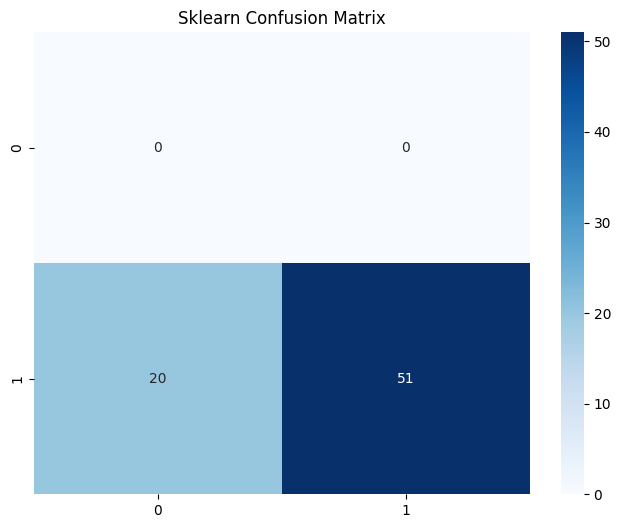

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix as sklearn_confusion_matrix,
)

# Load the dataset
data = pd.read_csv(
    "./ion_binary_classification.csv", header=None
)  # Read without headers

# Assign column names, including the first column
data.columns = [f"V{i}" for i in range(0, 35)] + ["Class"]

# Convert target column 'Class' to binary values
data["Class"] = np.where(data["Class"] == "good", 1, 0)

# Convert all feature columns to numeric types
data.iloc[:, :-1] = data.iloc[:, :-1].apply(pd.to_numeric, errors="coerce")

# Check for any NaN values
# print(data.isnull().sum())

# Handle NaN values (drop or fill)
data.dropna(inplace=True)  # or data.fillna(data.mean(), inplace=True)

# Separate features (X) and target (y)
X = data.drop("Class", axis=1).values  # Features
y = data["Class"].values  # Target

# Split the dataset into training and test sets (80:20)
train_size = int(0.8 * len(data))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Sklearn Naive Bayes
sklearn_nb = GaussianNB()
sklearn_nb.fit(X_train, y_train)
y_pred_sklearn = sklearn_nb.predict(X_test)

# Calculate metrics for Sklearn
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
precision_sklearn = precision_score(y_test, y_pred_sklearn)
recall_sklearn = recall_score(y_test, y_pred_sklearn)
f1_score_sklearn = f1_score(y_test, y_pred_sklearn)

# Confusion Matrix for Sklearn
confusion_matrix_sklearn = sklearn_confusion_matrix(y_test, y_pred_sklearn)

print(f"Sklearn Accuracy: {accuracy_sklearn * 100:.2f}%")
print(f"Sklearn Precision: {precision_sklearn * 100:.2f}%")
print(f"Sklearn Recall: {recall_sklearn * 100:.2f}%")
print(f"Sklearn F1 Score: {f1_score_sklearn * 100:.2f}%")
print(f"Confusion Matrix: \n{confusion_matrix_sklearn}")

# Plotting the Sklearn confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_sklearn, annot=True, fmt="d", cmap="Blues")
plt.title("Sklearn Confusion Matrix")
plt.show()